In [1]:
print("Day 3 Start")

Day 3 Start


In [15]:
import yfinance as yf
data = yf.download ("SPY", start = "2025-01-01", end = "2026-01-01")

data['daily_change'] = data['Close'].pct_change()
data['daily_return'] = (data['daily_change'] + 1)
data['cumulative_return'] = (data['daily_return']).cumprod()

print(data['cumulative_return'].tail())

[*********************100%***********************]  1 of 1 completed

2025-12-24    1.194731
2025-12-26    1.194609
2025-12-29    1.190352
2025-12-30    1.188899
2025-12-31    1.180090
Name: cumulative_return, dtype: float64


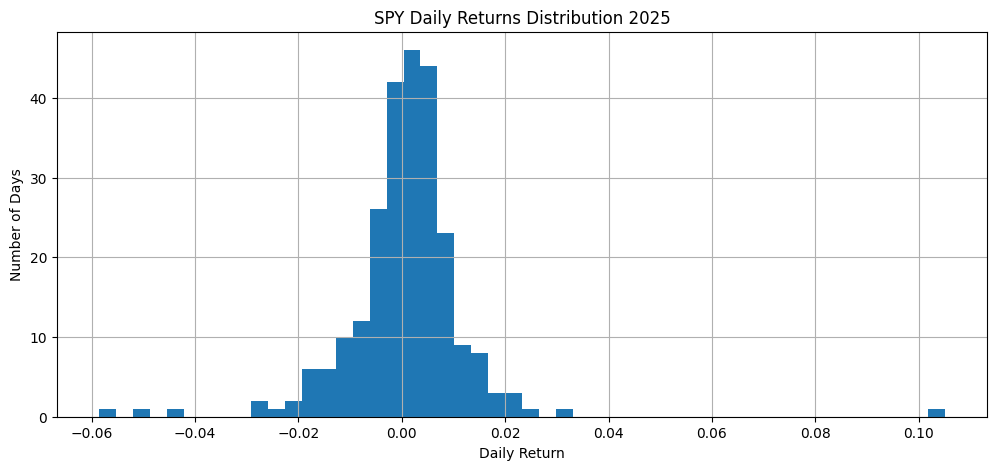

In [19]:
import matplotlib.pyplot as plt

(data['daily_change']).hist(bins=50, figsize = (12,5))
plt.title('SPY Daily Returns Distribution 2025')
plt.xlabel('Daily Return')
plt.ylabel('Number of Days')
plt.grid(True)
plt.show()


In [20]:
print(f"Skewness: {data['daily_change'].skew():.4f}")
print(f"Kurtosis: {data['daily_change'].kurt():.4f}")

Skewness: 1.5013
Kurtosis: 23.4864


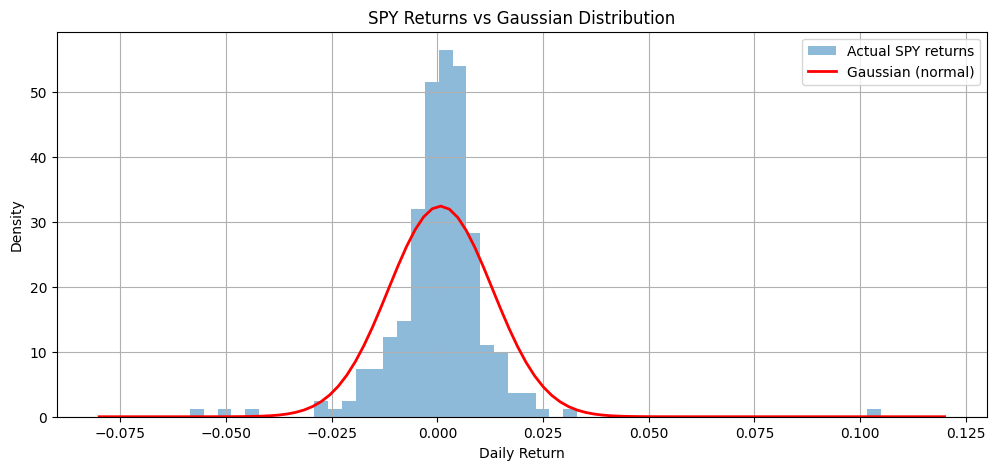

In [28]:
import numpy as np

fig, ax = plt.subplots(figsize=(12,5))

#actual returns
data['daily_change'].hist(bins=50, ax=ax, density=True, alpha=0.5, label='Actual SPY returns')

#What a Gaussian would look like
mu = data['daily_change'].mean()
sigma = data['daily_change'].std()
x = np.linspace(-0.08, 0.12, 100)
gaussian = (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)
ax.plot(x, gaussian, 'r-', linewidth=2, label='Gaussian (normal)')

plt.title("SPY Returns vs Gaussian Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

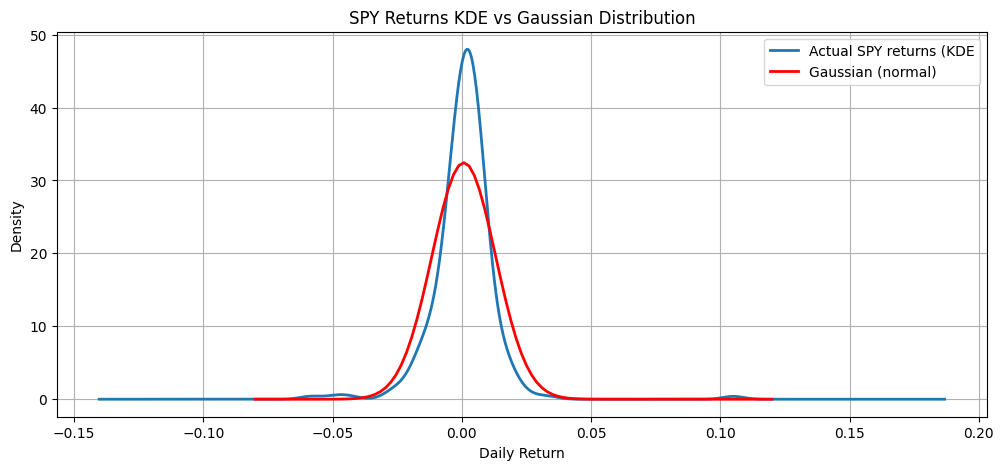

In [35]:
fig, ax = plt.subplots(figsize=(12,5))

#actual returns (KDE smooth curve) -> Kernel Density Estimation
data['daily_change'].plot.kde(ax=ax, label='Actual SPY returns (KDE', linewidth=2)

#What a Gaussian would look like
mu = data['daily_change'].mean()
sigma = data['daily_change'].std()
x = np.linspace(-0.08, 0.12, 100)
gaussian = (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)
ax.plot(x, gaussian, 'r-', linewidth=2, label='Gaussian (normal)')

plt.title("SPY Returns KDE vs Gaussian Distribution")
plt.xlabel("Daily Return")
plt.legend()
plt.grid(True)
plt.show()

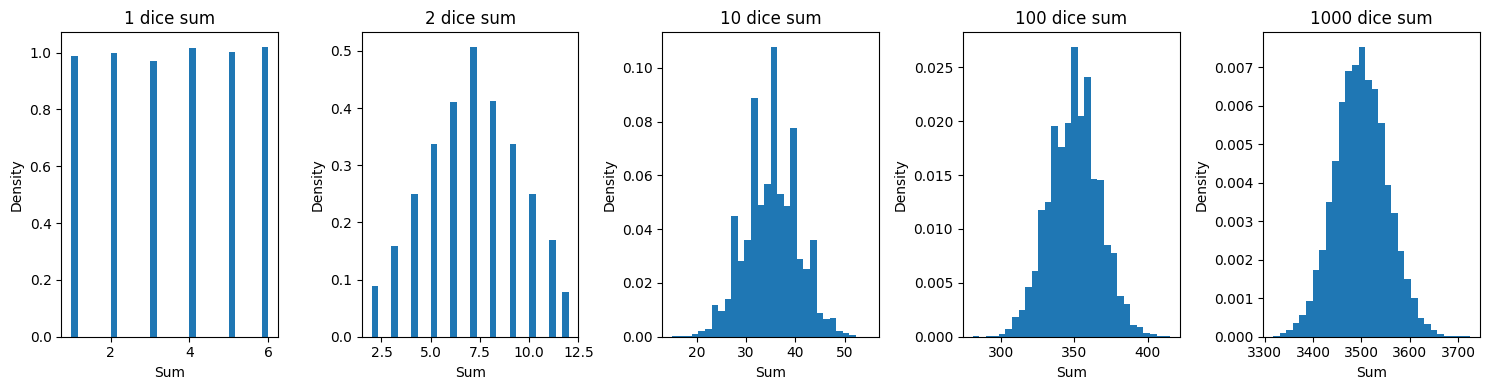

In [48]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(15,4))

for idx, n_dice in enumerate ([1, 2, 10, 100, 1000]):
    rolls = np.random.randint(1, 7, size=(10000, n_dice)).sum(axis=1)
    axes[idx].hist(rolls, bins=30, density=True)
    axes[idx].set_title(f"{n_dice} dice sum")
    axes[idx].set_xlabel("Sum")
    axes[idx].set_ylabel("Density")

plt.tight_layout()
plt.show()